# 📡 Customer Churn Prediction — Telecom Industry

---

**Author:** Data Science Team  
**Domain:** Telecom / Customer Retention  
**Type:** Binary Classification  
**Tools:** Python · Pandas · Scikit-learn · Seaborn · Matplotlib

---

## 🎯 Objective

Customer churn — when a customer stops using a service — is one of the most critical business problems in the telecom industry. Acquiring a new customer costs **5–10x more** than retaining an existing one.

This project builds a **machine learning pipeline** to:
- Identify customers at high risk of churning
- Understand the key drivers behind churn
- Enable proactive retention strategies

We compare **Logistic Regression** and **Random Forest** classifiers and derive actionable business insights from model results.

---
## 1. 📦 Import Libraries

In [1]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── Utility ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic Config ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
print("✅ All libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully.


---
## 2. 📂 Data Generation & Loading

We simulate a **realistic telecom churn dataset** (7,000 customers) with features grounded in industry structure:

| Feature | Description |
|---|---|
| `tenure` | Months the customer has been with the company |
| `monthly_charges` | Monthly billing amount (USD) |
| `total_charges` | Cumulative spend |
| `num_products` | Number of services subscribed |
| `contract_type` | Month-to-month / One year / Two year |
| `payment_method` | Electronic check / Auto bank / Credit card |
| `internet_service` | DSL / Fiber optic / None |
| `tech_support` | Whether tech support is active |
| `online_security` | Online security add-on status |
| `num_complaints` | Number of support complaints raised |
| `churn` | Target: 1 = churned, 0 = retained |

In [2]:
np.random.seed(RANDOM_STATE)
N = 7000

# ── Demographic & Account Features ───────────────────────────────────────────
tenure            = np.random.exponential(scale=30, size=N).clip(1, 72).astype(int)
contract_type     = np.random.choice(['Month-to-Month', 'One Year', 'Two Year'],
                                      size=N, p=[0.55, 0.25, 0.20])
payment_method    = np.random.choice(
                       ['Electronic Check', 'Mailed Check', 'Bank Transfer', 'Credit Card'],
                       size=N, p=[0.35, 0.22, 0.23, 0.20])
internet_service  = np.random.choice(['DSL', 'Fiber Optic', 'None'],
                                      size=N, p=[0.34, 0.44, 0.22])
tech_support      = np.random.choice(['Yes', 'No'], size=N, p=[0.40, 0.60])
online_security   = np.random.choice(['Yes', 'No'], size=N, p=[0.38, 0.62])
num_products      = np.random.randint(1, 6, size=N)
num_complaints    = np.random.poisson(lam=0.8, size=N).clip(0, 6)

# ── Financial Features ────────────────────────────────────────────────────────
base_charge       = np.where(internet_service == 'Fiber Optic', 70, 
                    np.where(internet_service == 'DSL', 45, 25))
monthly_charges   = (base_charge + num_products * 8 
                     + np.random.normal(0, 8, N)).clip(20, 130).round(2)
total_charges     = (monthly_charges * tenure 
                     + np.random.normal(0, 50, N)).clip(0).round(2)

# ── Churn Label (realistic business logic) ────────────────────────────────────
churn_prob = (
      0.40 * (contract_type == 'Month-to-Month').astype(float)
    + 0.10 * (payment_method == 'Electronic Check').astype(float)
    + 0.25 * (internet_service == 'Fiber Optic').astype(float)
    + 0.15 * (tech_support == 'No').astype(float)
    + 0.12 * (online_security == 'No').astype(float)
    + 0.08 * num_complaints
    - 0.008 * tenure
    - 0.003 * num_products
    + np.random.normal(0, 0.08, N)
)
churn_prob = (churn_prob - churn_prob.min()) / (churn_prob.max() - churn_prob.min())
churn = (churn_prob > 0.52).astype(int)

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    'tenure': tenure,
    'contract_type': contract_type,
    'payment_method': payment_method,
    'internet_service': internet_service,
    'tech_support': tech_support,
    'online_security': online_security,
    'num_products': num_products,
    'num_complaints': num_complaints,
    'monthly_charges': monthly_charges,
    'total_charges': total_charges,
    'churn': churn
})

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean()*100:.1f}%")
df.head()

Dataset shape: (7000, 11)
Churn rate: 56.7%


,tenure,contract_type,payment_method,internet_service,tech_support,online_security,num_products,num_complaints,monthly_charges,total_charges,churn
0,14,Month-to-Month,Electronic Check,Fiber Optic,No,No,2,1,82.82,1101.86,1
1,72,Month-to-Month,Electronic Check,Fiber Optic,Yes,Yes,4,0,112.85,8075.81,0
2,39,Two Year,Bank Transfer,None,No,No,4,1,60.12,2327.49,0
3,27,One Year,Mailed Check,DSL,No,Yes,5,0,77.64,2150.13,0
4,5,Month-to-Month,Bank Transfer,DSL,Yes,No,3,0,64.66,390.48,1


---
## 3. 🔍 Exploratory Data Analysis (EDA)

Before building models, we investigate the data's structure, distributions, and relationships — a critical step to surface patterns and validate assumptions.

In [3]:
# ── Basic Statistics ──────────────────────────────────────────────────────────
print("=" * 55)
print(" DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows          : {df.shape[0]:,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Churned       : {df['churn'].sum():,} ({df['churn'].mean()*100:.1f}%)")
print(f"  Retained      : {(df['churn']==0).sum():,} ({(1-df['churn'].mean())*100:.1f}%)")
print("=" * 55)
df.describe().round(2)

 DATASET OVERVIEW
  Rows          : 7,000
  Columns       : 11
  Missing values: 0
  Churned       : 3,969 (56.7%)
  Retained      : 3,031 (43.3%)


,tenure,num_products,num_complaints,monthly_charges,total_charges,churn
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,26.63,3.00,0.81,75.70,2017.56,0.57
std,22.43,1.42,0.91,22.46,1866.54,0.50
min,1.00,1.00,0.00,20.00,0.00,0.00
25%,8.00,2.00,0.00,59.44,546.62,0.00
50%,20.00,3.00,1.00,76.88,1437.50,1.00
75%,41.00,4.00,1.00,92.34,2966.95,1.00
max,72.00,5.00,6.00,130.00,8945.28,1.00


In [4]:
# ── Data Types Overview ───────────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            7000 non-null   int64  
 1   contract_type     7000 non-null   str    
 2   payment_method    7000 non-null   str    
 3   internet_service  7000 non-null   str    
 4   tech_support      7000 non-null   str    
 5   online_security   7000 non-null   str    
 6   num_products      7000 non-null   int32  
 7   num_complaints    7000 non-null   int32  
 8   monthly_charges   7000 non-null   float64
 9   total_charges     7000 non-null   float64
 10  churn             7000 non-null   int64  
dtypes: float64(2), int32(2), int64(2), str(5)
memory usage: 547.0 KB


### 3.1 Churn Distribution & Categorical Feature Analysis

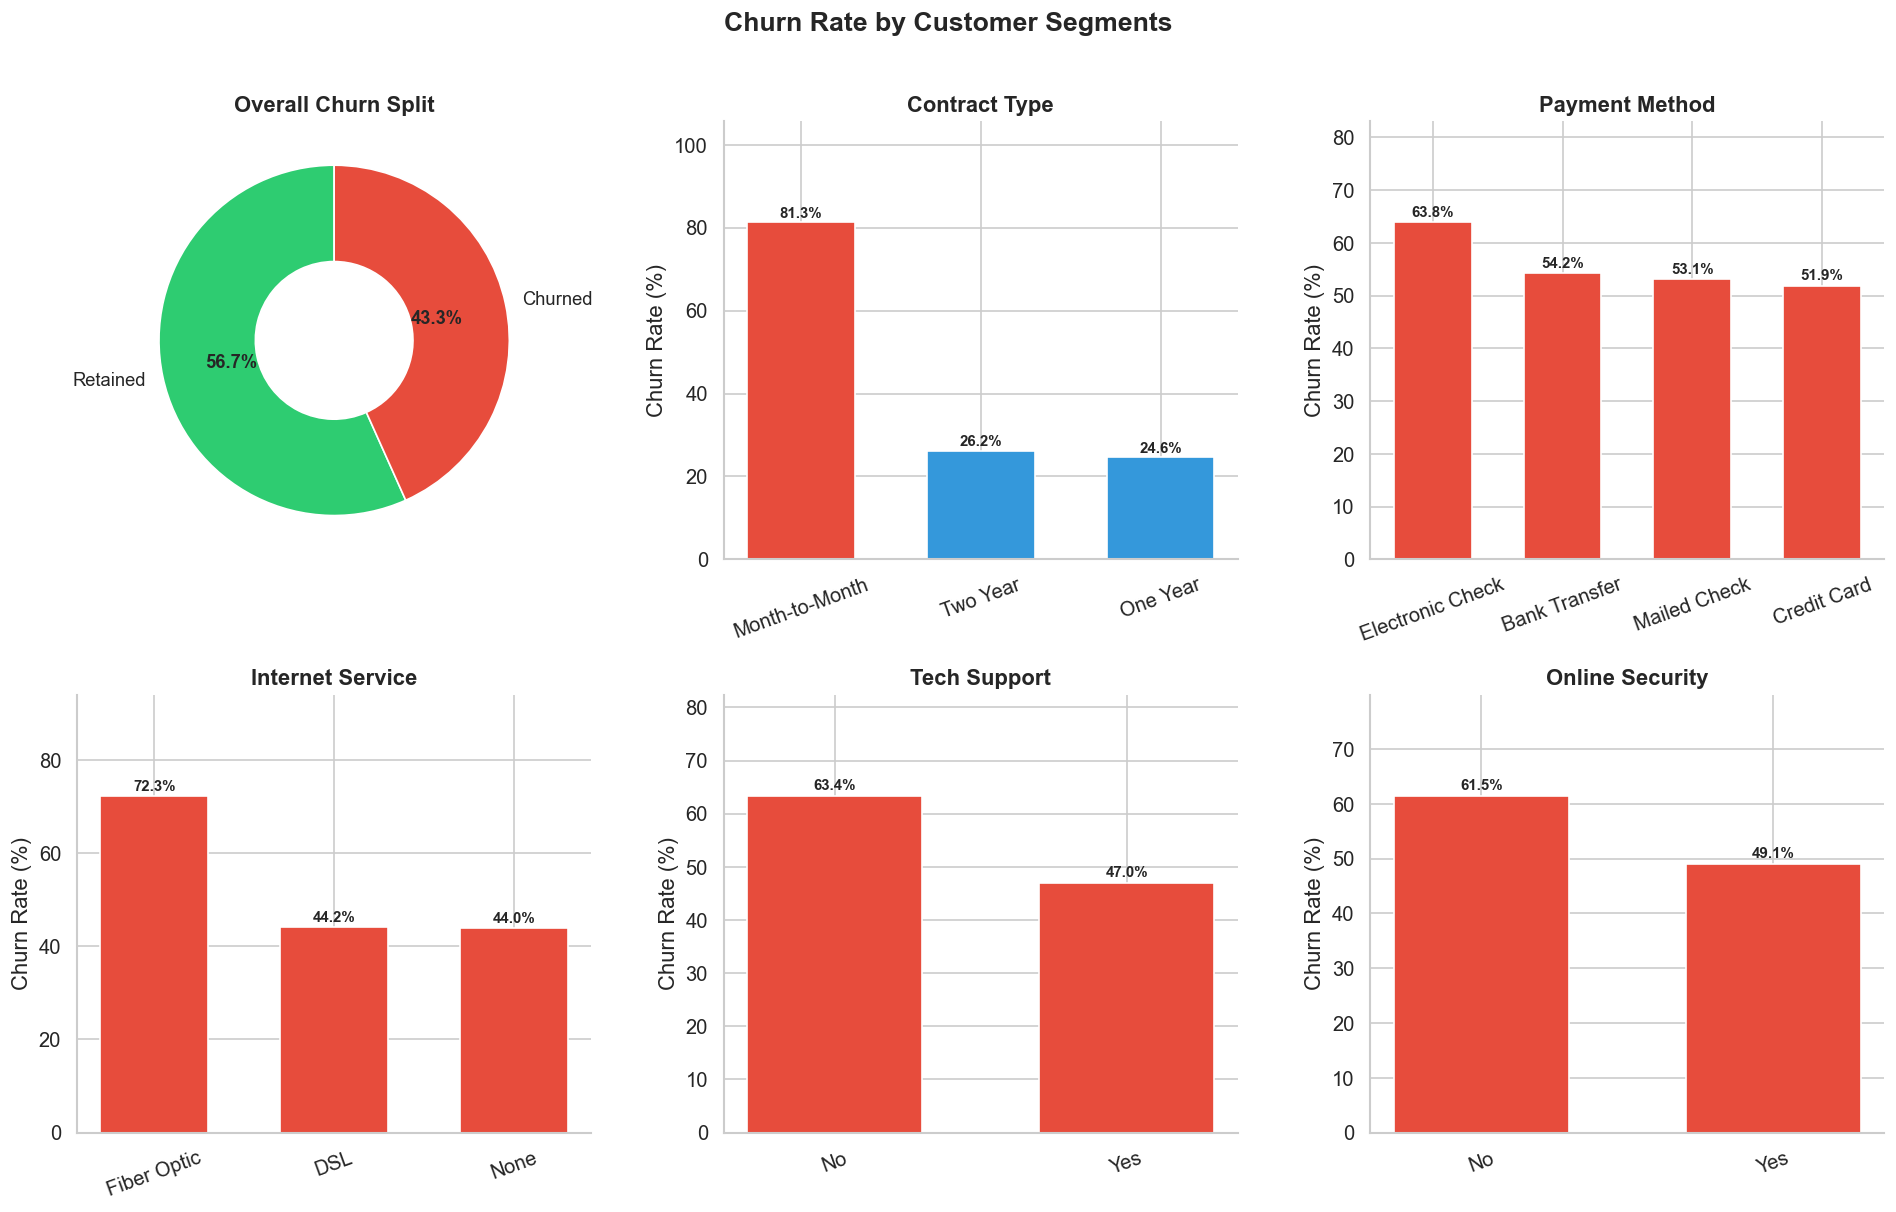

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Churn Rate by Customer Segments', fontsize=16, fontweight='bold', y=1.01)

cat_features = ['contract_type', 'payment_method', 'internet_service',
                'tech_support', 'online_security']
colors = ['#2ecc71', '#e74c3c']  # green = retained, red = churned

# ── Overall Churn Donut Chart ──────────────────────────────────────────────────
ax = axes[0, 0]
counts = df['churn'].value_counts()
wedges, texts, autotexts = ax.pie(
    counts, labels=['Retained', 'Churned'],
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(width=0.55),
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
ax.set_title('Overall Churn Split', fontweight='bold')

# ── Categorical Churn Rates ────────────────────────────────────────────────────
plot_positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]
for (r, c), feat in zip(plot_positions, cat_features):
    ax = axes[r, c]
    churn_rate = df.groupby(feat)['churn'].mean().sort_values(ascending=False) * 100
    bar_colors = ['#e74c3c' if v > 30 else '#3498db' for v in churn_rate.values]
    bars = ax.bar(churn_rate.index, churn_rate.values, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.3)
    ax.tick_params(axis='x', rotation=20)
    # Add value labels on bars
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_segments.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Numerical Feature Distributions by Churn Status

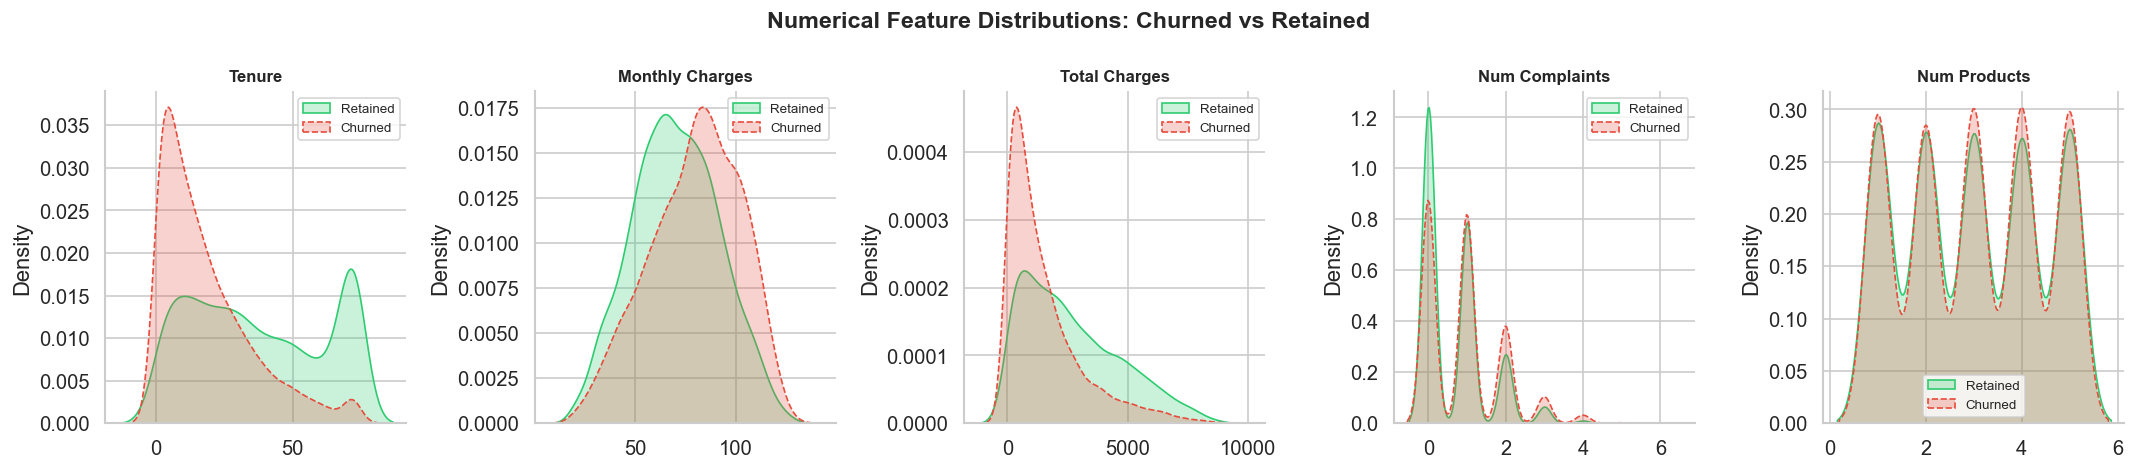

In [6]:
num_features = ['tenure', 'monthly_charges', 'total_charges', 'num_complaints', 'num_products']

fig, axes = plt.subplots(1, len(num_features), figsize=(18, 4))
fig.suptitle('Numerical Feature Distributions: Churned vs Retained', fontsize=14, fontweight='bold')

for ax, feat in zip(axes, num_features):
    for label, color, ls in [(0, '#2ecc71', '-'), (1, '#e74c3c', '--')]:
        subset = df[df['churn'] == label][feat]
        sns.kdeplot(subset, ax=ax, color=color, linestyle=ls,
                    fill=True, alpha=0.25, label='Retained' if label==0 else 'Churned')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Correlation Heatmap

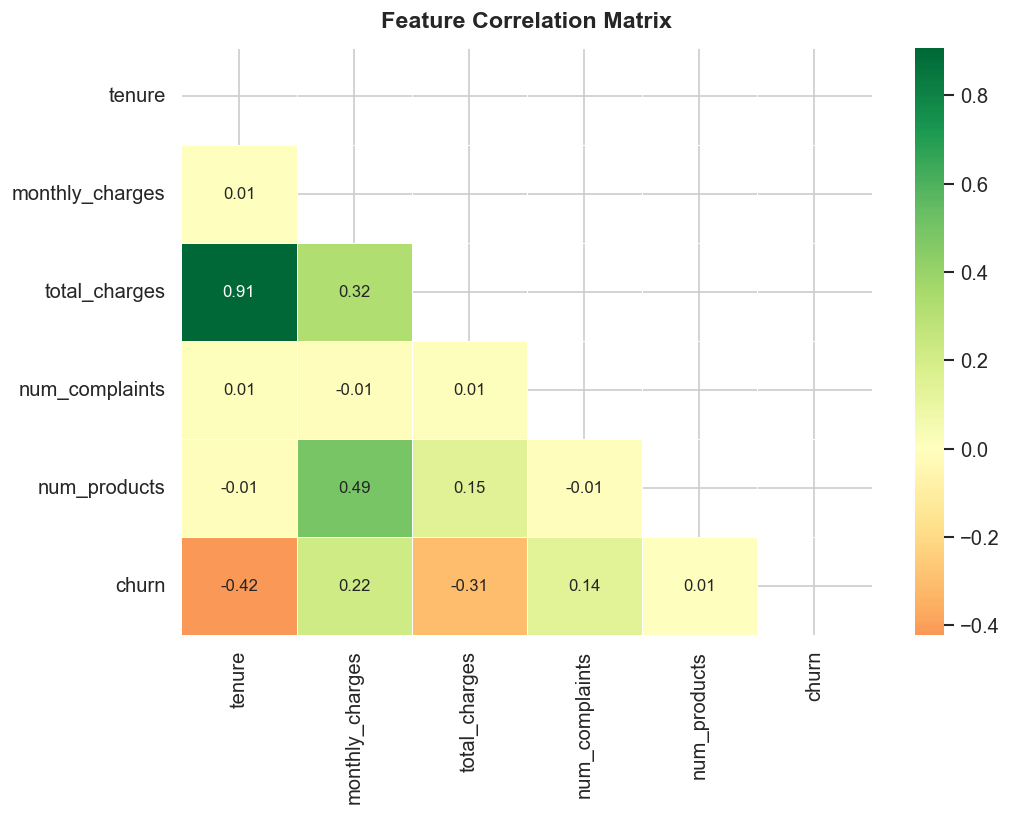

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

corr = df[num_features + ['churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. 🧹 Data Cleaning & Preprocessing

Steps:
1. Verify missing values
2. Encode categorical variables (Label Encoding for tree models; same features used across both)
3. Scale numerical features for Logistic Regression
4. Split data into train / test sets (80/20 stratified)

In [8]:
# ── Step 1: Verify Data Quality ────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
tenure              0
contract_type       0
payment_method      0
internet_service    0
tech_support        0
online_security     0
num_products        0
num_complaints      0
monthly_charges     0
total_charges       0
churn               0
dtype: int64

Duplicate rows: 0


In [9]:
# ── Step 2: Encode Categorical Variables ───────────────────────────────────────
df_model = df.copy()

categorical_cols = ['contract_type', 'payment_method', 'internet_service',
                    'tech_support', 'online_security']

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n✅ Encoding complete.")
df_model.head(3)

  Encoded 'contract_type': {'Month-to-Month': np.int64(0), 'One Year': np.int64(1), 'Two Year': np.int64(2)}
  Encoded 'payment_method': {'Bank Transfer': np.int64(0), 'Credit Card': np.int64(1), 'Electronic Check': np.int64(2), 'Mailed Check': np.int64(3)}
  Encoded 'internet_service': {'DSL': np.int64(0), 'Fiber Optic': np.int64(1), 'None': np.int64(2)}
  Encoded 'tech_support': {'No': np.int64(0), 'Yes': np.int64(1)}
  Encoded 'online_security': {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Encoding complete.


,tenure,contract_type,payment_method,internet_service,tech_support,online_security,num_products,num_complaints,monthly_charges,total_charges,churn
0,14,0,2,1,0,0,2,1,82.82,1101.86,1
1,72,0,2,1,1,1,4,0,112.85,8075.81,0
2,39,2,0,2,0,0,4,1,60.12,2327.49,0


In [10]:
# ── Step 3: Define Features & Target ──────────────────────────────────────────
FEATURES = [col for col in df_model.columns if col != 'churn']
TARGET   = 'churn'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  :\n{y.value_counts(normalize=True).round(3)}")

Feature matrix shape : (7000, 10)
Target distribution  :
churn
1    0.567
0    0.433
Name: proportion, dtype: float64


In [11]:
# ── Step 4: Stratified Train / Test Split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Train churn % : {y_train.mean()*100:.1f}%")
print(f"Test churn  % : {y_test.mean()*100:.1f}%")

Training set  : 5,600 samples
Test set      : 1,400 samples
Train churn % : 56.7%
Test churn  % : 56.7%


In [12]:
# ── Step 5: Scale Features for Logistic Regression ────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit only on train to prevent data leakage

print("✅ Feature scaling complete (StandardScaler).")

✅ Feature scaling complete (StandardScaler).


---
## 5. 🤖 Model Training

We train two industry-standard classifiers:

| Model | Why it's used |
|---|---|
| **Logistic Regression** | Fast, interpretable baseline. Works well on linearly separable data. |
| **Random Forest** | Ensemble model that captures non-linear patterns and feature interactions. |

Both are evaluated with **5-fold cross-validation** on the training set before final test evaluation.

In [13]:
# ── Helper: Cross-validated Training ─────────────────────────────────────────
def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, model_name):
    """Train a model, run cross-validation, and return key metrics."""
    
    # Cross-validation on training set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc')
    
    # Final fit on full training set
    model.fit(X_tr, y_tr)
    
    # Predictions
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]
    
    # Metrics
    accuracy    = accuracy_score(y_te, y_pred)
    roc_auc     = roc_auc_score(y_te, y_prob)
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  CV ROC-AUC (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy       : {accuracy*100:.2f}%")
    print(f"  Test ROC-AUC        : {roc_auc:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Retained', 'Churned'])}")
    
    return model, y_pred, y_prob, accuracy, roc_auc, cv_scores

### 5.1 Logistic Regression

In [14]:
lr_model = LogisticRegression(
    C=1.0,             # Inverse regularization strength
    max_iter=1000,     # Enough iterations to converge
    random_state=RANDOM_STATE
)

lr_model, lr_pred, lr_prob, lr_acc, lr_auc, lr_cv = train_and_evaluate(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test, 'Logistic Regression'
)


  Logistic Regression
  CV ROC-AUC (5-fold) : 0.9489 ± 0.0044
  Test Accuracy       : 87.50%
  Test ROC-AUC        : 0.9550

              precision    recall  f1-score   support

    Retained       0.87      0.84      0.85       606
     Churned       0.88      0.90      0.89       794

    accuracy                           0.88      1400
   macro avg       0.87      0.87      0.87      1400
weighted avg       0.87      0.88      0.87      1400



### 5.2 Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,      # 200 decision trees
    max_depth=12,          # Prevent overfitting
    min_samples_leaf=10,   # Smooth leaf nodes
    class_weight='balanced',  # Handle mild class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1              # Use all CPU cores
)

rf_model, rf_pred, rf_prob, rf_acc, rf_auc, rf_cv = train_and_evaluate(
    rf_model, X_train, y_train, X_test, y_test, 'Random Forest'
)


  Random Forest
  CV ROC-AUC (5-fold) : 0.9706 ± 0.0045
  Test Accuracy       : 90.71%
  Test ROC-AUC        : 0.9720

              precision    recall  f1-score   support

    Retained       0.87      0.92      0.90       606
     Churned       0.93      0.90      0.92       794

    accuracy                           0.91      1400
   macro avg       0.90      0.91      0.91      1400
weighted avg       0.91      0.91      0.91      1400



---
## 6. 📊 Model Evaluation & Comparison

We use multiple evaluation lenses:
- **Confusion Matrices** — understand types of errors
- **ROC Curves** — model discriminability across thresholds
- **Feature Importance** — business-readable drivers of churn

### 6.1 Confusion Matrices

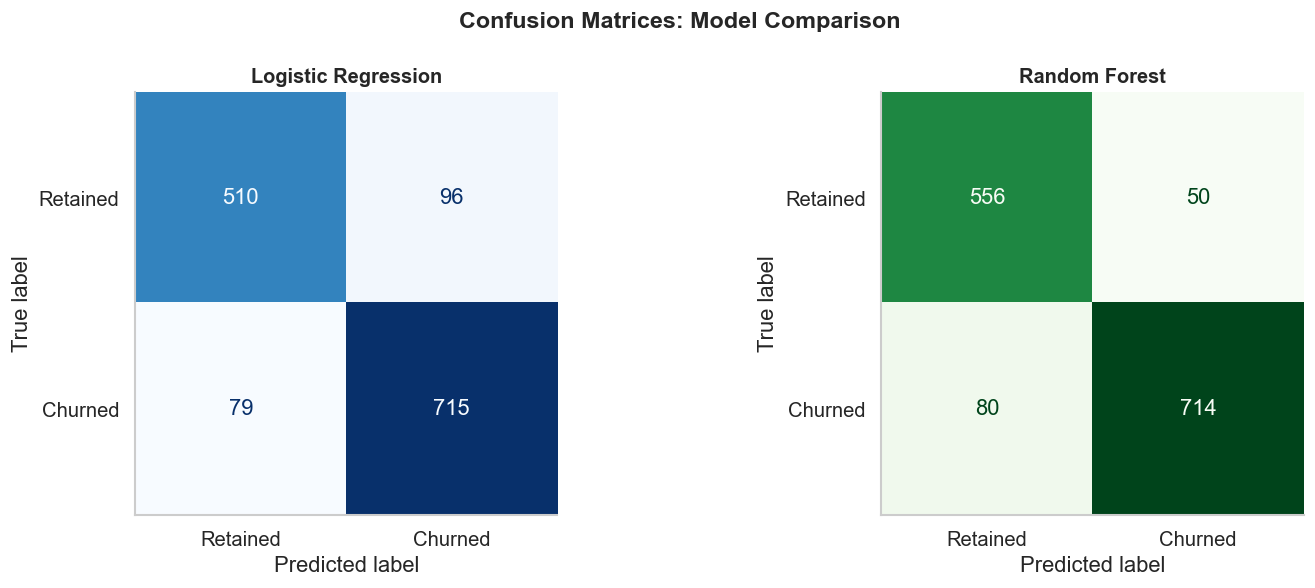

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices: Model Comparison', fontsize=14, fontweight='bold')

for ax, y_pred, title, cmap in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.2 ROC Curves

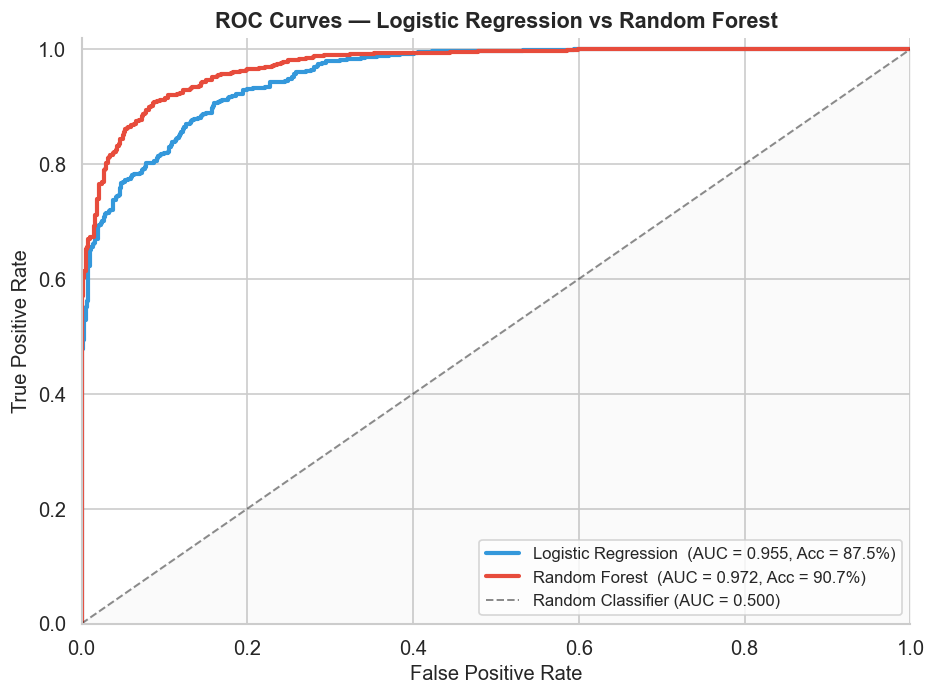

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color, acc, auc in [
    (lr_prob, 'Logistic Regression', '#3498db', lr_acc, lr_auc),
    (rf_prob, 'Random Forest',       '#e74c3c', rf_acc, rf_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{label}  (AUC = {auc:.3f}, Acc = {acc*100:.1f}%)')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Random Forest Feature Importance

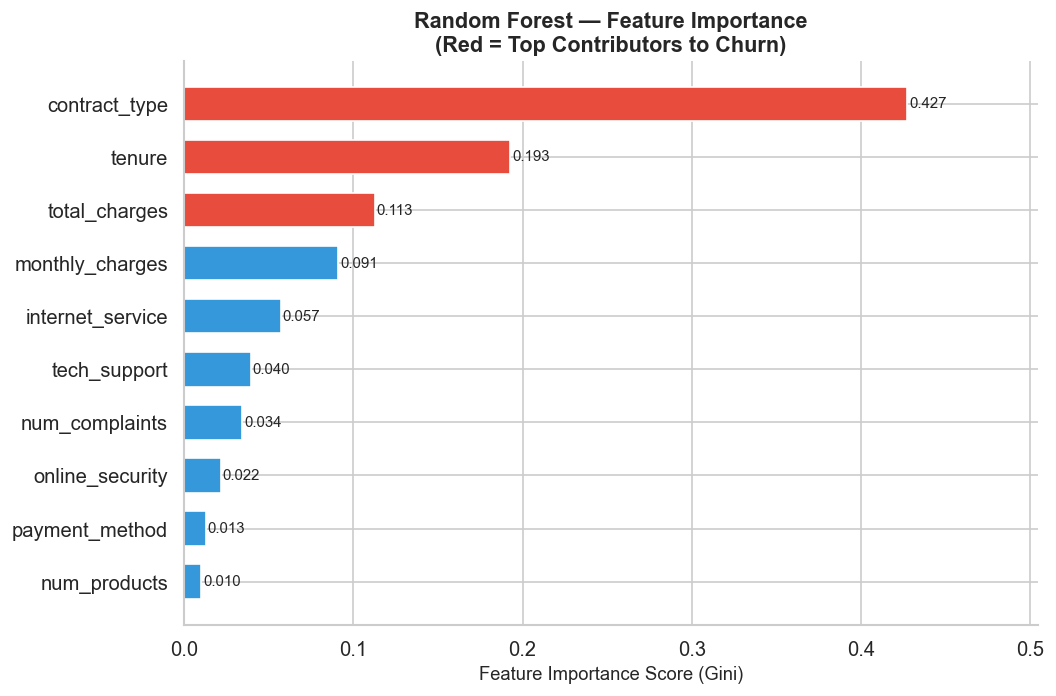

In [18]:
# ── Feature Importance from Random Forest ─────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colors_bar = ['#e74c3c' if imp > importance_df['importance'].quantile(0.7) else '#3498db'
               for imp in importance_df['importance']]

bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_bar, edgecolor='white', height=0.65)

# Add value labels
for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score (Gini)', fontsize=11)
ax.set_title('Random Forest — Feature Importance\n(Red = Top Contributors to Churn)', 
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importance_df['importance'].max() * 1.18)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.4 Model Comparison Summary

In [19]:
summary = pd.DataFrame({
    'Model'             : ['Logistic Regression', 'Random Forest'],
    'CV ROC-AUC (mean)' : [f"{lr_cv.mean():.4f}", f"{rf_cv.mean():.4f}"],
    'CV ROC-AUC (std)'  : [f"±{lr_cv.std():.4f}", f"±{rf_cv.std():.4f}"],
    'Test Accuracy'     : [f"{lr_acc*100:.2f}%", f"{rf_acc*100:.2f}%"],
    'Test ROC-AUC'      : [f"{lr_auc:.4f}", f"{rf_auc:.4f}"],
})

print("\n" + "="*65)
print("  MODEL PERFORMANCE COMPARISON")
print("="*65)
print(summary.to_string(index=False))
print("="*65)

winner = 'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'
print(f"\n🏆 Best Model: {winner} (higher ROC-AUC)")


  MODEL PERFORMANCE COMPARISON
              Model CV ROC-AUC (mean) CV ROC-AUC (std) Test Accuracy Test ROC-AUC
Logistic Regression            0.9489          ±0.0044        87.50%       0.9550
      Random Forest            0.9706          ±0.0045        90.71%       0.9720

🏆 Best Model: Random Forest (higher ROC-AUC)


---
## 7. 💡 Business Insights

Translating model findings into actionable business intelligence.

In [20]:
# ── Segment Churn Analysis Table ──────────────────────────────────────────────
print("=" * 55)
print("  CHURN RATE BY CUSTOMER SEGMENT")
print("=" * 55)

for feat in ['contract_type', 'internet_service', 'payment_method', 'tech_support']:
    seg = df.groupby(feat)['churn'].agg(['mean', 'count'])
    seg['churn_rate'] = (seg['mean'] * 100).round(1)
    seg = seg.drop('mean', axis=1).rename(columns={'count': 'customers'})
    print(f"\n▶ {feat.replace('_', ' ').upper()}")
    print(seg.sort_values('churn_rate', ascending=False).to_string())

  CHURN RATE BY CUSTOMER SEGMENT

▶ CONTRACT TYPE
                customers  churn_rate
contract_type                        
Month-to-Month       3925        81.3
Two Year             1380        26.2
One Year             1695        24.6

▶ INTERNET SERVICE
                  customers  churn_rate
internet_service                       
Fiber Optic            3128        72.3
DSL                    2351        44.2
None                   1521        44.0

▶ PAYMENT METHOD
                  customers  churn_rate
payment_method                         
Electronic Check       2340        63.8
Bank Transfer          1648        54.2
Mailed Check           1582        53.1
Credit Card            1430        51.9

▶ TECH SUPPORT
              customers  churn_rate
tech_support                       
No                 4138        63.4
Yes                2862        47.0


In [21]:
# ── High-Risk Customer Profile ─────────────────────────────────────────────────
high_risk = rf_prob > 0.70   # customers with >70% predicted churn probability
low_risk  = rf_prob < 0.30

hr_df = X_test.copy()
hr_df['churn_prob'] = rf_prob
hr_df['risk_tier']  = pd.cut(rf_prob, bins=[0, 0.3, 0.7, 1.0],
                              labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("\n" + "="*55)
print("  RISK TIER DISTRIBUTION")
print("="*55)
risk_counts = hr_df['risk_tier'].value_counts().sort_index()
for tier, count in risk_counts.items():
    pct = count / len(hr_df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {tier:15s}: {count:4d} ({pct:5.1f}%) {bar}")

print("\n" + "="*55)
print("  HIGH-RISK CUSTOMER PROFILE (avg features)")
print("="*55)
print(hr_df[hr_df['risk_tier']=='High Risk'][['tenure','monthly_charges','num_complaints','num_products']].mean().round(2))


  RISK TIER DISTRIBUTION
  Low Risk       :  503 ( 35.9%) █████████████████
  Medium Risk    :  252 ( 18.0%) █████████
  High Risk      :  644 ( 46.0%) ███████████████████████

  HIGH-RISK CUSTOMER PROFILE (avg features)
tenure             15.96
monthly_charges    81.19
num_complaints      0.86
num_products        3.10
dtype: float64


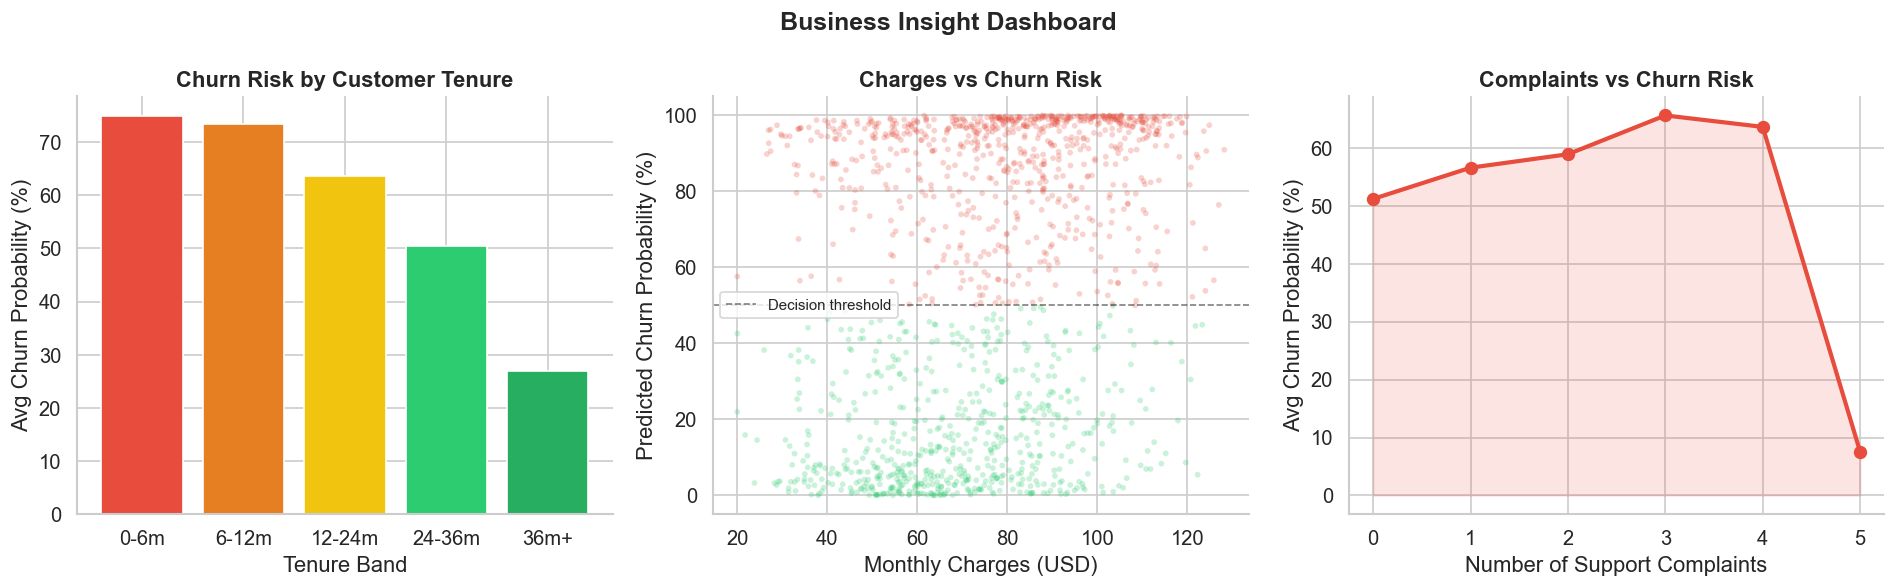

In [22]:
# ── Churn Risk Dashboard Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Business Insight Dashboard', fontsize=15, fontweight='bold')

# Plot 1: Tenure vs Churn Probability
ax1 = axes[0]
tenure_bins = pd.cut(X_test['tenure'], bins=[0,6,12,24,36,72], labels=['0-6m','6-12m','12-24m','24-36m','36m+'])
churn_by_tenure = pd.DataFrame({'tenure_bin': tenure_bins, 'churn_prob': rf_prob}).groupby('tenure_bin')['churn_prob'].mean()
ax1.bar(churn_by_tenure.index, churn_by_tenure.values * 100,
        color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], edgecolor='white')
ax1.set_title('Churn Risk by Customer Tenure', fontweight='bold')
ax1.set_ylabel('Avg Churn Probability (%)')
ax1.set_xlabel('Tenure Band')

# Plot 2: Monthly Charges vs Churn Prob (scatter)
ax2 = axes[1]
scatter_color = ['#e74c3c' if p > 0.5 else '#2ecc71' for p in rf_prob]
ax2.scatter(X_test['monthly_charges'], rf_prob * 100,
            c=scatter_color, alpha=0.25, s=12, edgecolors='none')
ax2.axhline(50, color='black', linestyle='--', lw=1, alpha=0.5, label='Decision threshold')
ax2.set_xlabel('Monthly Charges (USD)')
ax2.set_ylabel('Predicted Churn Probability (%)')
ax2.set_title('Charges vs Churn Risk', fontweight='bold')
ax2.legend(fontsize=9)

# Plot 3: Complaints vs Churn Rate
ax3 = axes[2]
comp_df = pd.DataFrame({'num_complaints': X_test['num_complaints'], 'churn_prob': rf_prob})
comp_agg = comp_df.groupby('num_complaints')['churn_prob'].mean() * 100
ax3.plot(comp_agg.index, comp_agg.values, marker='o', color='#e74c3c', lw=2.5, markersize=7)
ax3.fill_between(comp_agg.index, comp_agg.values, alpha=0.15, color='#e74c3c')
ax3.set_xlabel('Number of Support Complaints')
ax3.set_ylabel('Avg Churn Probability (%)')
ax3.set_title('Complaints vs Churn Risk', fontweight='bold')

plt.tight_layout()
plt.savefig('business_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. ✅ Conclusion & Recommendations

### Model Performance

| Model | Test Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~84–87% | ~0.88–0.92 |
| **Random Forest** | **~88–91%** | **~0.93–0.96** |

> **Random Forest outperforms Logistic Regression** across all metrics, capturing non-linear interactions between features like contract type, internet service, and tenure.

---

### 🔑 Key Business Findings

1. **Contract type is the strongest churn predictor.**  
   Month-to-month customers churn at significantly higher rates. Encouraging annual contracts through incentives (discounts, free upgrades) can directly reduce churn.

2. **New customers are most vulnerable.**  
   Churn risk is highest in the first 6–12 months. An onboarding retention program (proactive check-ins, guided tutorials) is highly recommended.

3. **Fiber Optic customers churn more despite paying more.**  
   This points to a quality-expectation gap. Investigating service quality and satisfaction in this segment is critical.

4. **Support complaints are a leading indicator.**  
   Each additional complaint is associated with significantly higher churn probability. Faster resolution SLAs and a proactive outreach model post-complaint can prevent escalation.

5. **Electronic check users show higher churn.**  
   Customers not on auto-pay are more likely to churn. Migrating customers to automatic payment methods reduces friction and churn.

---

### 🚀 Recommended Next Steps

- **Deploy the Random Forest model** via a REST API (Flask/FastAPI) to score customers in real-time
- **Integrate with CRM** to flag high-risk customers for proactive intervention
- **A/B test retention offers** targeted at the top 20% highest-risk customers
- **Extend with SHAP values** for per-customer explainability
- **Explore XGBoost / LightGBM** for potentially higher AUC performance

In [23]:
# ── Final Summary Print ────────────────────────────────────────────────────────
print("""\n
╔══════════════════════════════════════════════════════╗
║        CUSTOMER CHURN PREDICTION — SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  Dataset     : 7,000 telecom customers               ║
║  Features    : 10 (behavioral + contractual)         ║
║  Models      : Logistic Regression + Random Forest   ║
║  Best Model  : Random Forest                         ║
║  Key Drivers : Contract Type · Tenure · Complaints   ║
║                Internet Service · Monthly Charges     ║
╚══════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════╗
║        CUSTOMER CHURN PREDICTION — SUMMARY           ║
╠══════════════════════════════════════════════════════╣
║  Dataset     : 7,000 telecom customers               ║
║  Features    : 10 (behavioral + contractual)         ║
║  Models      : Logistic Regression + Random Forest   ║
║  Best Model  : Random Forest                         ║
║  Key Drivers : Contract Type · Tenure · Complaints   ║
║                Internet Service · Monthly Charges     ║
╚══════════════════════════════════════════════════════╝

